The dataset used is a customer churn dataset from kaggle 

In [1]:
# Importing important libraries
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression # Classification model 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import LabelEncoder, StandardScaler,OneHotEncoder
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,roc_curve, roc_auc_score,confusion_matrix,classification_report
data=pd.read_csv("C:/Users/Rajeev/Downloads/churn1.csv")
# Exploratory Data Analysis
data.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,CUST00001,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,...,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,CUST00002,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,...,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,CUST00003,Female,No,No,No,42.0,Yes,Yes,DSL,No,...,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,CUST00004,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,...,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,CUST00005,Male,Yes,Yes,Yes,17.0,Yes,NaN,Fiber optic,Yes,...,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes


In [2]:
data.describe()

,tenure,MonthlyCharges
count,69433.000000,69612.000000
mean,30.516858,60.588548
std,89.873767,111.509588
min,-10.000000,18.000000
25%,10.000000,29.670000
50%,20.000000,41.190000
75%,35.000000,63.882500
max,999.000000,1499.770000


In [3]:
data.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        70000 non-null  object 
 1   gender            69252 non-null  object 
 2   SeniorCitizen     69341 non-null  object 
 3   Partner           66470 non-null  object 
 4   Dependents        66435 non-null  object 
 5   tenure            69433 non-null  float64
 6   PhoneService      70000 non-null  object 
 7   MultipleLines     68132 non-null  object 
 8   InternetService   70000 non-null  object 
 9   OnlineSecurity    67078 non-null  object 
 10  OnlineBackup      67253 non-null  object 
 11  DeviceProtection  67106 non-null  object 
 12  TechSupport       67267 non-null  object 
 13  StreamingTV       67173 non-null  object 
 14  StreamingMovies   67215 non-null  object 
 15  Contract          70000 non-null  object 
 16  PaperlessBilling  70000 non-null  object

In [4]:
data.dtypes

customerID           object
gender               object
SeniorCitizen        object
Partner              object
Dependents           object
tenure              float64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [5]:
# Data Cleaning & Data Preprocessing
data.isnull().sum()
# CLeaning this dataset will involve drop the columns which is not needed to proceed,fixing missing values and update the datatypes if they are not suitable for the data it is holding

customerID             0
gender               748
SeniorCitizen        659
Partner             3530
Dependents          3565
tenure               567
PhoneService           0
MultipleLines       1868
InternetService        0
OnlineSecurity      2922
OnlineBackup        2747
DeviceProtection    2894
TechSupport         2733
StreamingTV         2827
StreamingMovies     2785
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

In [6]:
# Stage 1 : Dropping the unnecessary columns
data=data.drop(columns=['customerID'],axis=1) 
data.head()
# Dropped 'customerID' column because it adds no predictive value
# Dropped TotalCharges
print(data['SeniorCitizen'].unique())
print(data['SeniorCitizen'].dtype)

['0' '1' 'No' 'Yes' nan 'not senior']
object


In [7]:
# From the dataset we can see that in the SeniorCitizen column, some values are in the form of 0's and 1's while some are in Yes or No
# To clean this, we need to standardize the value to ensure that the column is holding the standard values
# To do this , we need to map the values

senior_mapping={'0': 0,'1': 1,'No': 0,'Yes': 1,'not senior': 0}
data['SeniorCitizen'] = (data['SeniorCitizen'].astype(str).str.strip().map(senior_mapping).astype('Int64'))
data.head()

# The column was a mix of Strings, numeric values and NaNs. To fix this we standardize the value bu first converting the whole column to a string datatype,
# Then we remove the hidden spaces if they are present, thn w use the map function to standardize the values then we handle the NaN values with the fillna() function
# Then finally we convert everything to integer data type, hence standardizing the entire column

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Male,0,No,Yes,3.0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Month-to-month,No,Mailed check,68.61,205.83,Yes
1,Male,1,Yes,No,2.0,Yes,Yes,DSL,No,No,No internet service,Yes,NaN,No,One year,Yes,Bank transfer (automatic),23.15,46.3,No
2,Female,0,No,No,42.0,Yes,Yes,DSL,No,Yes,No,NaN,Yes,Yes,Month-to-month,No,Electronic check,42.63,1790.46,Yes
3,Female,0,No,Yes,40.0,Yes,Yes,Fiber optic,No,No,Yes,No,No,No internet service,Month-to-month,No,Electronic check,75.04,3001.6,No
4,Male,1,Yes,Yes,17.0,Yes,NaN,Fiber optic,Yes,No,Yes,No,No internet service,No,Two year,Yes,Electronic check,22.38,380.46,Yes


In [8]:
cols=['OnlineSecurity','OnlineBackup','DeviceProtection','InternetService','TechSupport','StreamingTV','StreamingMovies']
for col in cols:
    data[col]=data[col].fillna("No")

# Here in the above selected columns we had diffrent values like "No Internet Service" and mostly "No". Both of these values in the end indicate the same thing that is "No"
# To fix this we will handle the columns selected above and change all the values to "NO" to standardize the column

#Then for the column "MultipleLines" its the same issue that there are multiple values like "No" and NaN and "No Phone service" 
# To fix this we di use the fillna() function again
data['MultipleLines']=data['MultipleLines'].fillna("No")

In [9]:
data.isnull().sum()

gender               748
SeniorCitizen        659
Partner             3530
Dependents          3565
tenure               567
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod       3569
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

In [10]:
# Now we use mode to fill the categorical columns. We will use the most frequent value
cat_cols=['gender','Partner','Dependents','PaymentMethod']
for col in cat_cols:
    data[col]=data[col].fillna(data[col].mode()[0])

In [11]:
data.isnull().sum()

gender                 0
SeniorCitizen        659
Partner                0
Dependents             0
tenure               567
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges       388
TotalCharges        1062
Churn                  0
dtype: int64

In [12]:
# Now we fix the numerical columns (tenure and MonthlyCharges) by filling the missing/null values using the median
data['tenure']=data['tenure'].fillna(data['tenure'].median())
data['MonthlyCharges']=data['MonthlyCharges'].fillna(data['MonthlyCharges'].median())

In [13]:
data.isnull().sum()

gender                 0
SeniorCitizen        659
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV            0
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges        1062
Churn                  0
dtype: int64

In [14]:
# Now we fill in the missing TotalCharges values by simple multiplication nd for SeniorCitizen we replace the yes and no with 0 and 1 and chaneg the values to numeric datatypr and fill in the missing/null values using mediam
data['TotalCharges'] = data['TotalCharges'].fillna(data['MonthlyCharges'] * data['tenure'])
data['SeniorCitizen'] = data['SeniorCitizen'].fillna(0)
data.isnull().sum()
#as we can see now the data is fully clean and ready to be used to train the model using classification algorithm

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [15]:
data.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

--- MODEL PERFORMANCE ---
Accuracy:  0.7698
Precision: 0.6976
Recall:    0.8951
F1 Score:  0.7841
ROC AUC:   0.7893

Classification Report:
               precision    recall  f1-score   support

           0       0.88      0.66      0.75     11185
           1       0.70      0.90      0.78      9799

    accuracy                           0.77     20984
   macro avg       0.79      0.78      0.77     20984
weighted avg       0.79      0.77      0.77     20984



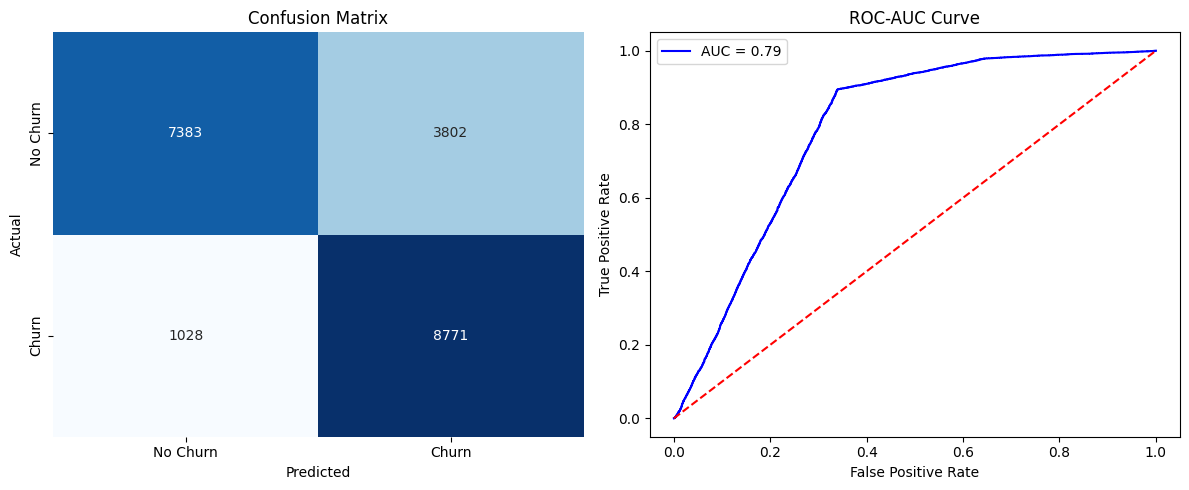

In [16]:
if 'customerID' in data.columns:
    data = data.drop(columns=['customerID'])

churn_mapping = {'YES': 1, 'Y': 1, 'CHURNED': 1, 'NO': 0, 'N': 0, 'NO CHURN': 0}
data['Churn'] = data['Churn'].astype(str).str.strip().str.upper().map(churn_mapping)
data = data.dropna(subset=['Churn'])
data['Churn'] = data['Churn'].astype(int)

# 3. LABEL ENCODING
le = LabelEncoder()
for col in data.select_dtypes(include=['object']).columns:
    data[col] = le.fit_transform(data[col].astype(str))

# 4. PREPARING X AND Y (Using float32 to save 50% more memory)
X = data.drop('Churn', axis=1).astype('float32')
y = data['Churn']

# 5. TRAIN-TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Using standard scaler to standardize the value
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LogisticRegression(max_iter=1000)
model.fit(X_train_scaled, y_train)

# 7. PREDICTIONS
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

# 8. Metrics Evaluation
print("--- MODEL PERFORMANCE ---")
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall:    {recall_score(y_test, y_pred):.4f}")
print(f"F1 Score:  {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# 9. VISUALIZATIONS
pl.figure(figsize=(12, 5))

# Confusion Matrix
pl.subplot(1, 2, 1)
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['No Churn', 'Churn'], 
            yticklabels=['No Churn', 'Churn'])
pl.title('Confusion Matrix')
pl.xlabel('Predicted')
pl.ylabel('Actual')

# ROC Curve
pl.subplot(1, 2, 2)
fpr, tpr, _ = roc_curve(y_test, y_prob)
pl.plot(fpr, tpr, color='blue', label=f'AUC = {roc_auc_score(y_test, y_prob):.2f}')
pl.plot([0, 1], [0, 1], color='red', linestyle='--')
pl.title('ROC-AUC Curve')
pl.xlabel('False Positive Rate')
pl.ylabel('True Positive Rate')
pl.legend()

pl.tight_layout()
pl.show()

Feature Selection:
- Removed 'customerID' as it does not contribute to prediction.
- Used label encoding to handle categorical variables efficiently.
- Avoided high-cardinality encoding to prevent memory issues.

## Final Results Summary

A Logistic Regression model was developed to predict customer churn based on the given dataset. The data was preprocessed by cleaning the target variable (`Churn`), removing irrelevant features such as `customerID`, and encoding categorical variables using Label Encoding to ensure memory efficiency.

The model was trained on 70% of the data and evaluated on the remaining 30% using multiple performance metrics.

### Model Performance

- Accuracy: 0.7698  
- Precision: 0.6976  
- Recall: 0.8951  
- F1 Score: 0.7841  
- ROC-AUC Score: 0.7893  

### Key Insights

- The model achieves a high recall (0.8951), meaning it successfully identifies most customers who are likely to churn. This is important in business scenarios where missing a churn customer can result in revenue loss.

- The precision (0.6976) indicates that the model slightly over-predicts churn, leading to some false positives.

- The F1 Score (0.7841) reflects a good balance between precision and recall.

- The ROC-AUC score (~0.79) shows that the model has good capability in distinguishing between churn and non-churn customers.

### Confusion Matrix Insights

- A large number of churn cases were correctly identified (True Positives).  
- False Negatives are relatively low, indicating that most churn customers were captured.  
- Some False Positives are present, meaning a few non-churn customers were incorrectly predicted
as churn.  

### Conclusion

The Logistic Regression model provides a strong baseline for churn prediction with good overall performance and high recall. It is effective for identifying at-risk customs and can  feature engineering techniques


 ### REFERENCE:
 Dataset : https://www.kaggle.com/datasets/blastchar/telco-customer-churn
 